(201, 1000)
Random Shuffling Mean: 0.5001598849598584
Random Shuffling 95% Confidence Interval: (np.float64(0.49801525047562195), np.float64(0.5023045194440948))
Actual Mean: 0.9695822943638335
Actual 95% Confidence Interval: (np.float64(0.9688740117953533), np.float64(0.9702905769323137))


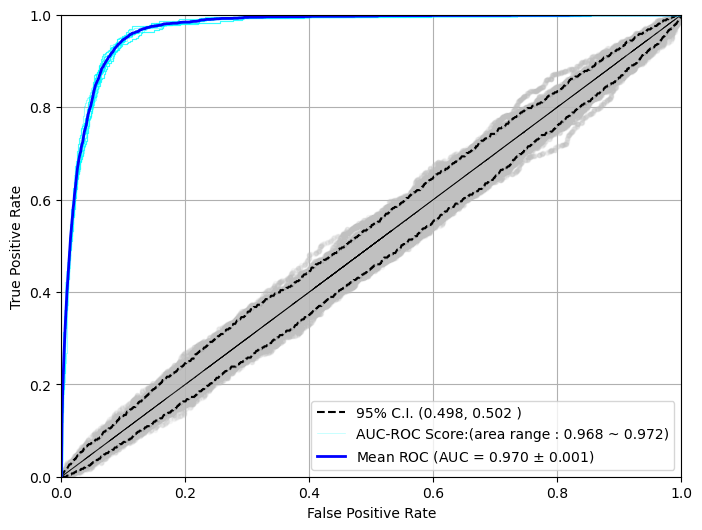

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import numpy as np
from sklearn.metrics import RocCurveDisplay, auc
import scipy.stats as stats

list1=[]
list2=[]
count = 0
tpr_list = []
fpr_list = []
tprs = []
random_aucs = []

# infile1 = open("tttt_random_label_file_200.txt","r")
# infile2 = open("tttt_random_pred_file_200.txt","r")
infile1 = open("random_true_label_200_add.txt","r")
infile2 = open("random_true_pred_200_add.txt","r")
mean_fpr = np.linspace(0, 1.0, 1000)

plt.figure(figsize=(8, 6))
for line1, line2 in zip(infile1, infile2):
    # print(line1[1:-2])
    line1_each = line1[1:-2].split(',')
    lines1 = []
    for f in line1_each:
        lines1.append(float(f))

    line2_each = line2[1:-2].split(',')
    lines2 = []
    for f in line2_each:
        lines2.append(float(f))


    # print ( len(lines1))
    count += 1
    plt.figure(1)

    lr_auc = roc_auc_score(lines1, lines2)
    fpr, tpr, _ = roc_curve(lines1, lines2)
    # print(len(fpr), len(tpr))
    random_aucs.append(lr_auc)
    

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    # aucs.append(lr_auc)

    plt.plot(fpr, tpr, marker='.', label=None, color='silver',linewidth=0.1,alpha=0.1)
    plt.plot([0, 1], [0, 1], 'k-', linewidth=0.5)
    # plt.plot(recall1, precision1, marker='.', label='Precision-Recall Score:(area = {:.3f})'.format(auc_precision_recall))
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.ylim(0.0,1.0)
    plt.xlim(0.0,1.0)

plt.figure(1)
print(np.asarray(tprs).shape)
mean_tpr = np.mean(tprs, axis=0)
std_tpr = np.std(tprs, axis=0)

pecent_95_upper = []
pecent_95_lower = []
tprs = np.asarray(tprs) 
for i in range(tprs.shape[1]):
    p = np.percentile(tprs[:,i], 97.5) 
    p_low = np.percentile(tprs[:,i], 2.5) 
    pecent_95_lower.append(p_low)
    pecent_95_upper.append(p)


mean_tpr[-1] = 1.0


def calculate_confidence_interval(data, confidence=0.95):
    # Convert data to a numpy array
    data = np.array(data)
    mean = np.mean(data)
    std = stats.sem(data)
    confidence_interval = stats.t.interval(confidence, len(data)-1, loc=mean, scale=std)
    return mean, confidence_interval
# Example usage
data = random_aucs  # Replace with your data list
mean, confidence_interval = calculate_confidence_interval(data)
print("Random Shuffling Mean:", mean)
print("Random Shuffling 95% Confidence Interval:", confidence_interval)


plt.plot(mean_fpr, pecent_95_upper, marker='^', label=r"95%% C.I. (%0.3f, %0.3f )"% (confidence_interval[0], confidence_interval[1]), color='black',linestyle='dashed',markersize=0.01)
plt.plot(mean_fpr, pecent_95_lower, marker='^', color='black',linestyle='dashed',markersize=0.01)
# plt.plot(mean_fpr, tprs_lower, marker='^',  color='darkgrey',linestyle='dashed',markersize=0.01)


infile1 = open("true_label_file_200.txt","r")
infile2 = open("true_pred_file_200.txt","r")



# infile1 = open("cana_label_file_200.txt","r")
# infile2 = open("cana_pred_file_200.txt","r")

true_tprs = []

aucs = []
count = 0
min_auc=float('inf')
max_auc=0.0
for line1, line2 in zip(infile1, infile2):
    line1_each = line1[1:-2].split(',')
    lines1 = []
    for f in line1_each:
        lines1.append(float(f))

    line2_each = line2[1:-2].split(',')
    lines2 = []
    for f in line2_each:
        lines2.append(float(f))

    lr_auc = roc_auc_score(lines1, lines2)
    min_auc = min(min_auc, lr_auc)
    max_auc = max(max_auc, lr_auc)
    fpr, tpr, _ = roc_curve(lines1, lines2)
    aucs.append(lr_auc)

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0

    true_tprs.append(interp_tpr)
    count += 1
    if count == 5:
        plt.plot(fpr, tpr, marker='.', label='AUC-ROC Score:(area range : %0.3f ~ %0.3f)'%(min_auc, max_auc),color='cyan', alpha=0.3,lw=0.5,markersize=0.01)
    else:
        plt.plot(fpr, tpr, marker='.', color='cyan', alpha=0.4, lw=0.8,markersize=0.01)

mean, confidence_interval = calculate_confidence_interval(aucs)
print("Actual Mean:", mean)
print("Actual 95% Confidence Interval:", confidence_interval)


std_auc = np.std(aucs)
mean_tpr = np.mean(true_tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)



plt.plot(mean_fpr, mean_tpr, marker='.', label= r"Mean ROC (AUC = %0.3f $\pm$ %0.3f)" % (mean_auc, std_auc),color='blue',lw=2,markersize=0.01)
plt.grid(True)
plt.legend(loc="lower right")
plt.show()

# plt.savefig("auc_roc_true_5_fold_200_add.png", dpi=1200)


# print(count)

(201, 1000)
Random Shuffling Mean: 0.5006946044078123
Random Shuffling 95% Confidence Interval: (np.float64(0.49892984520349276), np.float64(0.502459363612132))


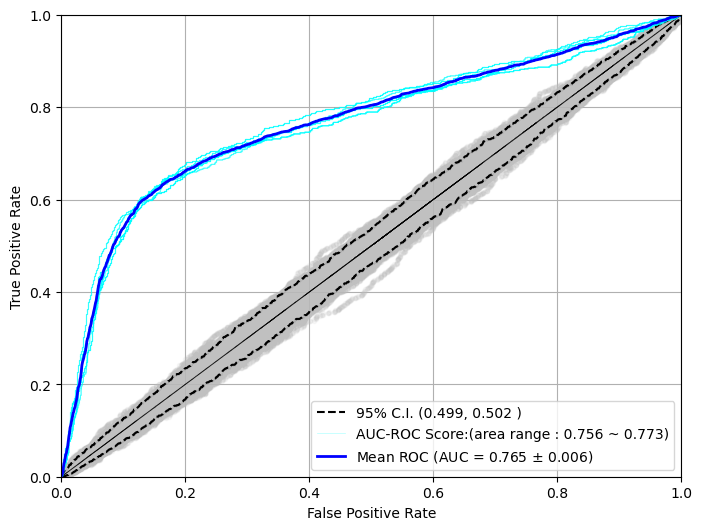

20


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import numpy as np
from sklearn.metrics import RocCurveDisplay, auc
import scipy.stats as stats

list1=[]
list2=[]
count = 0
tpr_list = []
fpr_list = []
tprs = []
random_aucs = []

# infile1 = open("tttt_random_label_file_200.txt","r")
# infile2 = open("tttt_random_pred_file_200.txt","r")
infile1 = open("tttt_random_label_200_add.txt","r")
infile2 = open("tttt_random_pred_200_add.txt","r")
mean_fpr = np.linspace(0, 1.0, 1000)

plt.figure(figsize=(8, 6))
for line1, line2 in zip(infile1, infile2):
    # print(line1[1:-2])
    line1_each = line1[1:-2].split(',')
    lines1 = []
    for f in line1_each:
        lines1.append(float(f))

    line2_each = line2[1:-2].split(',')
    lines2 = []
    for f in line2_each:
        lines2.append(float(f))


    # print ( len(lines1))
    count += 1
    plt.figure(1)

    lr_auc = roc_auc_score(lines1, lines2)
    fpr, tpr, _ = roc_curve(lines1, lines2)
    # print(len(fpr), len(tpr))
    random_aucs.append(lr_auc)
    
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    # aucs.append(lr_auc)

    plt.plot(fpr, tpr, marker='.', label=None, color='silver',linewidth=0.1,alpha=0.1)
    plt.plot([0, 1], [0, 1], 'k-', linewidth=0.5)
    # plt.plot(recall1, precision1, marker='.', label='Precision-Recall Score:(area = {:.3f})'.format(auc_precision_recall))
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.ylim(0.0,1.0)
    plt.xlim(0.0,1.0)

plt.figure(1)
print(np.asarray(tprs).shape)
mean_tpr = np.mean(tprs, axis=0)
std_tpr = np.std(tprs, axis=0)

pecent_95_upper = []
pecent_95_lower = []
tprs = np.asarray(tprs) 
for i in range(tprs.shape[1]):
    p = np.percentile(tprs[:,i], 97.5) 
    p_low = np.percentile(tprs[:,i], 2.5) 
    pecent_95_lower.append(p_low)
    pecent_95_upper.append(p)


mean_tpr[-1] = 1.0

def calculate_confidence_interval(data, confidence=0.95):
    # Convert data to a numpy array
    data = np.array(data)
    mean = np.mean(data)
    std = stats.sem(data)
    confidence_interval = stats.t.interval(confidence, len(data)-1, loc=mean, scale=std)
    return mean, confidence_interval
# Example usage
data = random_aucs  # Replace with your data list
mean, confidence_interval = calculate_confidence_interval(data)
print("Random Shuffling Mean:", mean)
print("Random Shuffling 95% Confidence Interval:", confidence_interval)



plt.plot(mean_fpr, pecent_95_upper, marker='^', label=r"95%% C.I. (%0.3f, %0.3f )"% (confidence_interval[0], confidence_interval[1]), color='black',linestyle='dashed',markersize=0.01)
plt.plot(mean_fpr, pecent_95_lower, marker='^', color='black',linestyle='dashed',markersize=0.01)
# plt.plot(mean_fpr, tprs_lower, marker='^',  color='darkgrey',linestyle='dashed',markersize=0.01)


# infile1 = open("true_label_file_200.txt","r")
# infile2 = open("true_pred_file_200.txt","r")



infile1 = open("cana_label_file_200.txt","r")
infile2 = open("cana_pred_file_200.txt","r")

true_tprs = []

aucs = []
count = 0
min_auc=float('inf')
max_auc=0.0
for line1, line2 in zip(infile1, infile2):
    line1_each = line1[1:-2].split(',')
    lines1 = []
    for f in line1_each:
        lines1.append(float(f))

    line2_each = line2[1:-2].split(',')
    lines2 = []
    for f in line2_each:
        lines2.append(float(f))

    lr_auc = roc_auc_score(lines1, lines2)
    min_auc = min(min_auc, lr_auc)
    max_auc = max(max_auc, lr_auc)
    fpr, tpr, _ = roc_curve(lines1, lines2)
    aucs.append(lr_auc)

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0

    true_tprs.append(interp_tpr)
    count += 1
    if count == 5:
        plt.plot(fpr, tpr, marker='.', label='AUC-ROC Score:(area range : %0.3f ~ %0.3f)'%(min_auc, max_auc),color='cyan', alpha=0.3,lw=0.5,markersize=0.01)
    else:
        plt.plot(fpr, tpr, marker='.', color='cyan', alpha=0.4, lw=0.8,markersize=0.01)


std_auc = np.std(aucs)
mean_tpr = np.mean(true_tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)

plt.plot(mean_fpr, mean_tpr, marker='.', label= r"Mean ROC (AUC = %0.3f $\pm$ %0.3f)" % (mean_auc, std_auc),color='blue',lw=2,markersize=0.01)
plt.grid(True)
plt.legend(loc="lower right")
plt.show()
# plt.savefig("auc_roc_cana_5_fold_200.png")
# plt.savefig("auc_roc_cana_5_fold_200_add.png", dpi=1200)


print(count)